# Initial Pipeline — Full Local Run

Runs the **full** base (`initial_pipeline`) experiment locally on your GPU and renders the summary tables + plots inline. Results are also saved to `outputs/initial_local/`. Expect ~45 min – 1.25 hr on an RTX 3050.

Run all cells top to bottom (Run All). Keep `experiment.ipynb` for the Vast.ai / reference run; this notebook is the local one.

In [1]:
%load_ext autoreload
%autoreload 2

## Imports and paths

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "initial_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

from initial_pipeline.core_pipeline import CONFIG, configure_vast_ai, prepare_data, print_task_summary
from initial_pipeline.experiment_runner import (
    run_experiment,
    build_cl_summary,
    print_and_save_comparison_tables,
    generate_all_plots,
)

Project root: c:\Users\Syakir\Downloads\Projects\fyp


c:\Users\Syakir\Downloads\Projects\fyp\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Runtime setup

`configure_vast_ai` sets the device and selects **bf16-mixed** on a supported GPU (else fp32), and points outputs at a local folder. `require_gpu=False` lets it fall back to CPU if no GPU is found — check the diagnostics say `Active device: CUDA`.

In [3]:
DATA_DIR   = str(PROJECT_ROOT / "data" / "processed")
OUTPUT_DIR = str(PROJECT_ROOT / "outputs" / "initial_local")

configure_vast_ai(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    require_gpu=False,
)

Runtime diagnostics

Python         : 3.11.9

PyTorch        : 2.3.1+cu121

CUDA available : True

GPU            : NVIDIA GeForce RTX 3050 Laptop GPU

...

CPU cores      : 12

Vast.ai        : NO

Active device  : CUDA

Precision      : bf16-mixed

{'paths': {'demand_csv': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\data\\processed\\demand_forecasting.csv',
  'rl_csv': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\data\\processed\\rl_environment.csv',
  'checkpoints': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\initial_local\\checkpoints',
  'results': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\initial_local\\results',
  'logs': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\initial_local\\logs',
  'plots': 'C:\\Users\\Syakir\\Downloads\\Projects\\fyp\\outputs\\initial_local\\plots'},
 'tasks': [{'task_id': 1,
   'name': 'Baseline_2023_H1',
   'start': '2023-01-01',
   'end': '2023-05-31',
   'regime': 'baseline'},
  {'task_id': 2,
   'name': 'MegaSale_2023',
   'start': '2023-06-01',
   'end': '2023-12-31',
   'regime': 'mega_sale'},
  {'task_id': 3,
   'name': 'Baseline_2024_H1',
   'start': '2024-01-01',
   'end': '2024-05-31',
   'regime': 'baseline'},
  {'task_id': 4,
   'name': 'MegaSale_202

## Load data

In [4]:
tft_tasks, rl_tasks, tft_df, rl_df = prepare_data()
print_task_summary(tft_tasks, rl_tasks)

Loading datasets...

Demand CSV  : 9,864 rows × 24 cols

RL CSV      : 9,864 rows × 19 cols

✓ Data loaded and cleaned

┏━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Task ┃ Name             ┃ Period                   ┃ TFT rows ┃ RL rows ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ 1    │ Baseline_2023_H1 │ 2023-01-01 -> 2023-05-31 │ 1,359    │ 1,359   │
│ 2    │ MegaSale_2023    │ 2023-06-01 -> 2023-12-31 │ 1,926    │ 1,926   │
│ 3    │ Baseline_2024_H1 │ 2024-01-01 -> 2024-05-31 │ 1,368    │ 1,368   │
│ 4    │ MegaSale_2024    │ 2024-06-01 -> 2024-12-31 │ 1,926    │ 1,926   │
│ 5    │ Baseline_2025_H1 │ 2025-01-01 -> 2025-05-31 │ 1,359    │ 1,359   │
│ 6    │ MegaSale_2025    │ 2025-06-01 -> 2025-12-31 │ 1,926    │ 1,926   │
└──────┴──────────────────┴──────────────────────────┴──────────┴─────────┘

## Run the full experiment

This is the long cell (~45 min – 1.25 hr). It trains all 4 forecasting methods and all 4 RL methods across the 6 tasks, evaluating after each task.

In [5]:
run_experiment(tft_tasks, rl_tasks)
print("Experiment complete")

==============================================================

  CONTINUAL LEARNING EXPERIMENT START

==============================================================

═══ MODEL TYPE: FORECASTING ═══

  ── CL Method: naive ──

...

Eval task 5: profit_index=1.1121  avg_episode_reward=6032.6912  cumulative_profit=55845344.4077  
pricing_regret=38.3622

Eval task 6: profit_index=1.1583  avg_episode_reward=7870.3050  cumulative_profit=55442179.4026  
pricing_regret=26.6764

Results saved → C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\results\all_metrics.csv

═══ EXPERIMENT COMPLETE (169.2 min) ═══

Experiment complete


## Results: summary, tables, plots

Renders inline and saves to `outputs/initial_local/results` and `.../plots`. RL primary metric is `profit_index` (method profit / naive fresh per-task); raw cumulative profit is kept as a reference table.

CL Summary (BWT / FWT / Forgetting):

model_type cl_method primary_metric  avg_final_perf  avg_online_perf     bwt     fwt  forgetting  avg_forgetting
forecasting     naive           mase         18.6805          18.7985  0.1417  0.0000     49.2952          9.8590
forecasting       ewc           mase          3.5178           3.9913  0.5683  2.2935      2.4795          0.4959
forecasting    replay           mase          5.1815           9.8748  5.6321  0.4418      5.4521          1.0904
forecasting      sdft           mase          6.0453           6.8465  0.9615  2.8663     20.2484          4.0497
         rl     naive   profit_index          0.9494           1.0000 -0.0607  0.0000      0.4544          0.0909
         rl       ewc   profit_index          1.0751           1.0824 -0.0088  0.0672      0.1622          0.0324
         rl    recall   profit_index          0.9664           1.0179 -0.0618 -0.0013      0.3942          0.0788
         rl      sdft   profit_index          1.0816           1.0691  0.0150  0.0484      0.0540          0.0108


  FORECASTING - MASE (lower is better)
           Task 1   Task 2  Task 3   Task 4  Task 5   Task 6
cl_method                                                   
ewc        0.6838   8.1546  0.7699   7.5103  0.8422   5.9873
naive      0.6322  19.9503  0.6293  41.7846  1.3278  48.4671
replay     0.5308  27.3615  2.3318  19.5450  1.3648   8.1153
sdft       0.6793  13.8396  0.4710  16.1005  0.6477   9.3408

  FORECASTING - sMAPE
            Task 1    Task 2   Task 3    Task 4   Task 5    Task 6
cl_method                                                         
ewc        56.6554   89.9060  64.7386   83.9984  66.3795   78.9122
naive      55.4004  126.0148  50.3822  140.6667  72.7314  159.9210
replay     50.0086  123.1171  79.8532  122.0502  80.4027   91.0035
sdft       57.9203  108.2891  47.9156  104.6504  41.3407   81.8635

  RL - PROFIT INDEX (vs naive fresh per-task, higher is better)
           Task 1  Task 2  Task 3  Task 4  Task 5  Task 6
cl_method                                     

Generating plots...

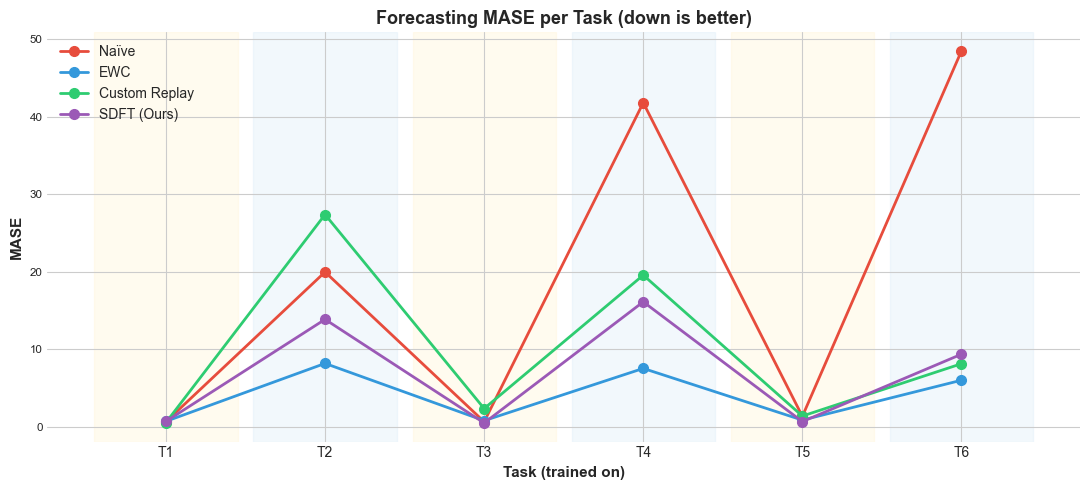

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/mase_online_forecasting.png

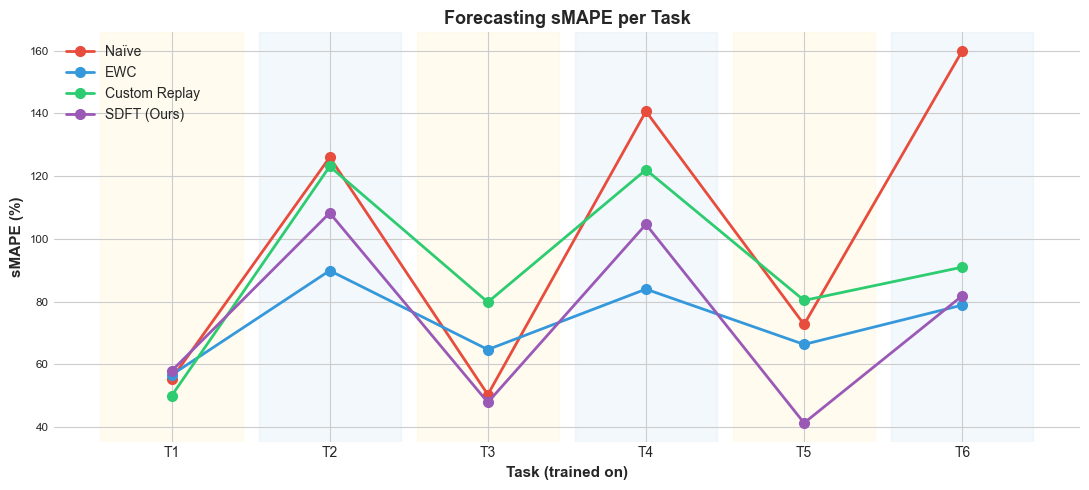

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/smape_online_forecasting.png

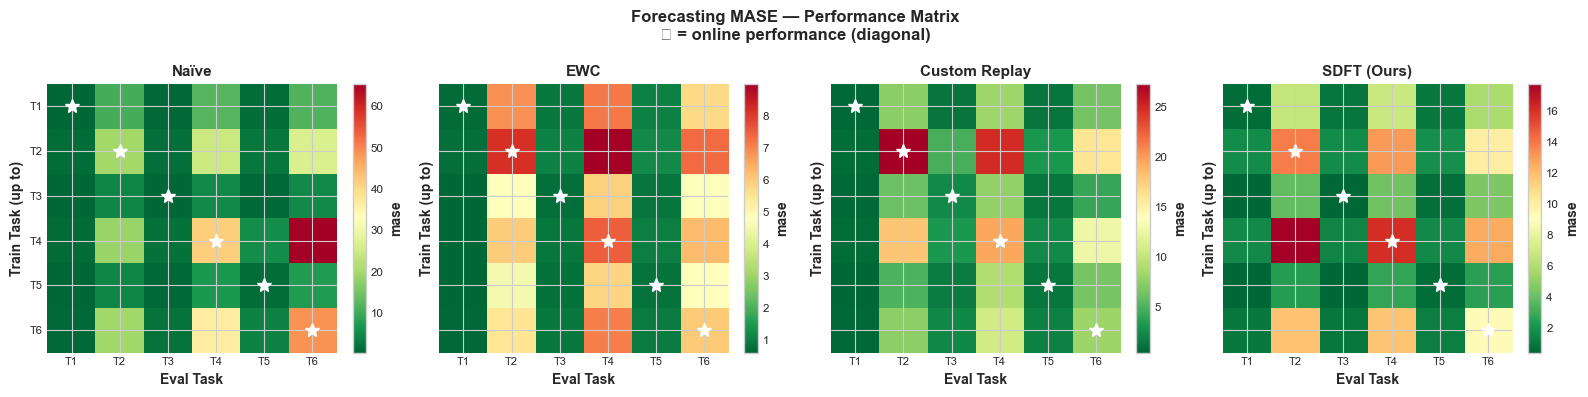

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/perfmat_mase_forecasting.png

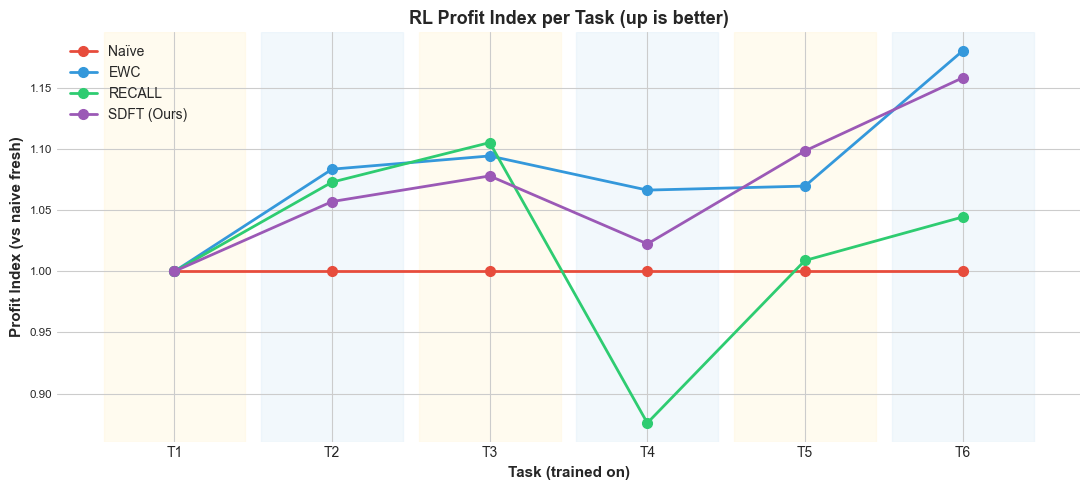

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/profit_index_online_rl.png

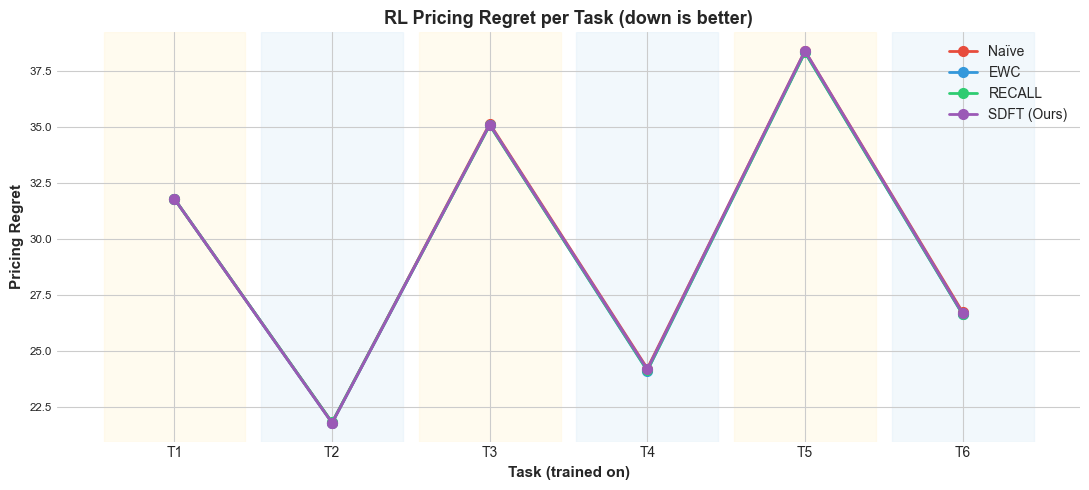

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/regret_online_rl.png

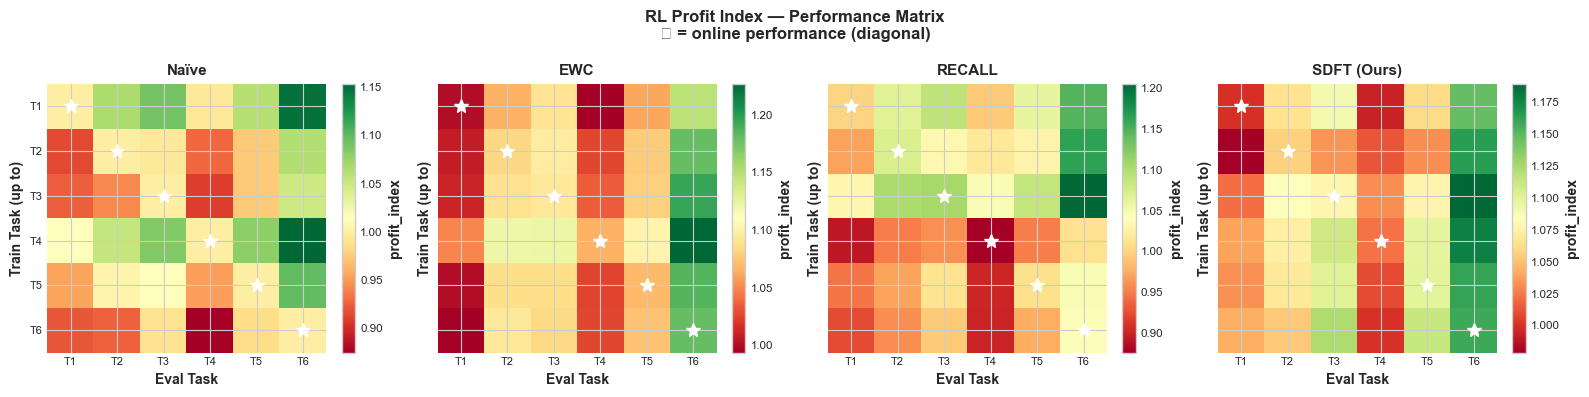

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/perfmat_profit_index_rl.png

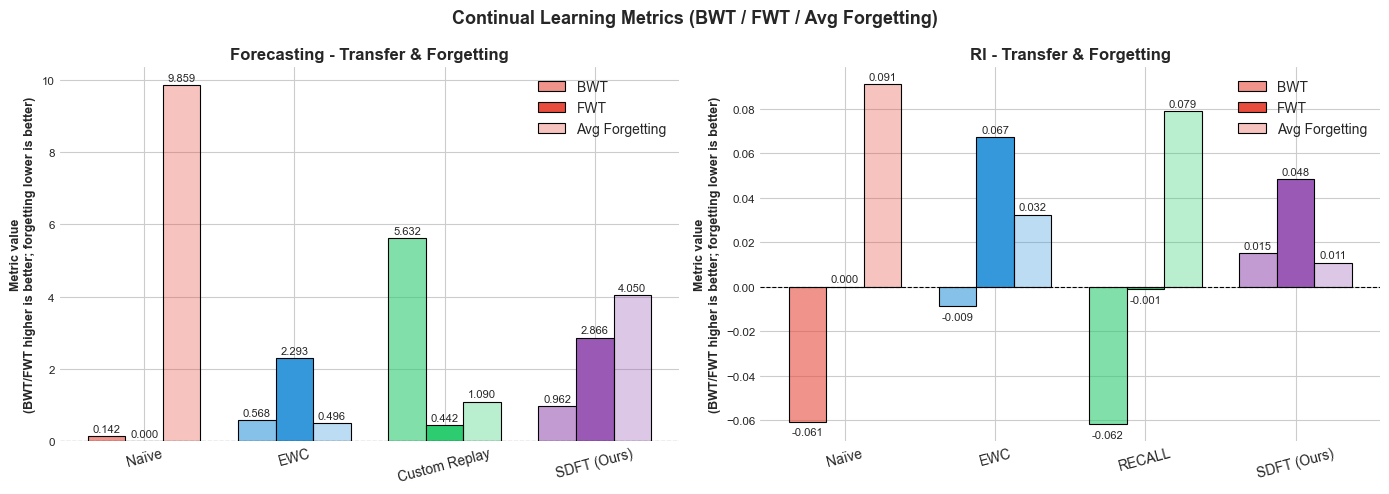

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/cl_transfer_forgetting_comparison.png

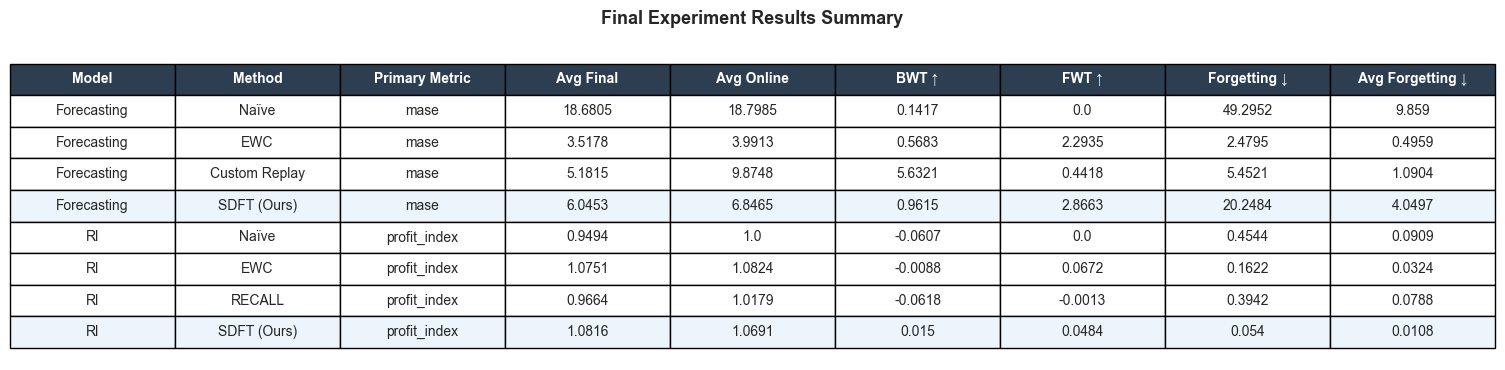

Saved: C:\Users\Syakir\Downloads\Projects\fyp\outputs\initial_local\plots/final_summary_table.png

All plots saved to plots/

,model_type,cl_method,primary_metric,avg_final_perf,avg_online_perf,bwt,fwt,forgetting,avg_forgetting
0,forecasting,naive,mase,18.6805,18.7985,0.1417,0.0000,49.2952,9.8590
1,forecasting,ewc,mase,3.5178,3.9913,0.5683,2.2935,2.4795,0.4959
2,forecasting,replay,mase,5.1815,9.8748,5.6321,0.4418,5.4521,1.0904
3,forecasting,sdft,mase,6.0453,6.8465,0.9615,2.8663,20.2484,4.0497
4,rl,naive,profit_index,0.9494,1.0000,-0.0607,0.0000,0.4544,0.0909
5,rl,ewc,profit_index,1.0751,1.0824,-0.0088,0.0672,0.1622,0.0324
6,rl,recall,profit_index,0.9664,1.0179,-0.0618,-0.0013,0.3942,0.0788
7,rl,sdft,profit_index,1.0816,1.0691,0.0150,0.0484,0.0540,0.0108


In [6]:
cl_summary = build_cl_summary()
tables = print_and_save_comparison_tables(cl_summary)
generate_all_plots(cl_summary)
cl_summary